# stagev2 visualization

This notebook reads generated stagev2 outputs. It does not retrain models and does not call APIs.

Before opening the notebook, generate the reports from the `stagev2` project root (the directory containing `run_stagev2.py`, `requirements.txt`, `src/`, and `stage_core/`) with the current system or Conda Python:

```powershell
python -m pip install -r requirements.txt
python .\run_stagev2.py --data-root .\input\raw
```


In [19]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path('../output/stagev2/final_report')
RUN_DIR = Path('../output/stagev2/run_external_accuracy_selection')

ranking_path = OUTPUT_DIR / 'stagev2_model_ranking_by_external_accuracy.csv'
external_path = OUTPUT_DIR / 'stagev2_external_performance_report.csv'
cv_path = OUTPUT_DIR / 'stagev2_cv_summary.csv'
pred_path = OUTPUT_DIR / 'stagev2_test_predictions_all_models.csv'
oof_path = OUTPUT_DIR / 'stagev2_oof_predictions_top10.csv'

for p in [ranking_path, external_path, cv_path, pred_path, oof_path]:
    print(p, 'exists=', p.exists())


..\output\stagev2\final_report\stagev2_model_ranking_by_external_accuracy.csv exists= True
..\output\stagev2\final_report\stagev2_external_performance_report.csv exists= True
..\output\stagev2\final_report\stagev2_cv_summary.csv exists= True
..\output\stagev2\final_report\stagev2_test_predictions_all_models.csv exists= True
..\output\stagev2\final_report\stagev2_oof_predictions_top10.csv exists= True


## 1. Top 20 models by external accuracy


,model_name,group,feature_block,external_accuracy,external_balanced_accuracy,external_sensitivity,external_specificity,external_f1,external_roc_auc,external_pr_auc,external_mcc,external_tn,external_fp,external_fn,external_tp
0,early_middle__svc__poly3,two_stage_raw,early_middle,0.845070,0.846429,0.942857,0.750000,0.857143,0.856349,0.849876,0.704702,27,9,2,33
1,early_middle_scale__svc__poly3,sequential_scale,early_middle_scale,0.845070,0.846429,0.942857,0.750000,0.857143,0.849206,0.836852,0.704702,27,9,2,33
2,all_plus_interactions__svc__poly3,three_stage_full_interaction,all_plus_interactions,0.802817,0.804365,0.914286,0.694444,0.820513,0.841270,0.837007,0.622726,25,11,3,32
3,middle__svc__poly3,single_stage_middle_moderate,middle,0.802817,0.803968,0.885714,0.722222,0.815789,0.850000,0.857225,0.615306,26,10,4,31
4,all__svc__poly3,three_stage_raw,all,0.802817,0.803968,0.885714,0.722222,0.815789,0.850000,0.844211,0.615306,26,10,4,31
5,all_plus_interactions__svc__poly2,three_stage_full_interaction,all_plus_interactions,0.788732,0.790476,0.914286,0.666667,0.810127,0.844444,0.840936,0.598298,24,12,3,32
6,early_middle__lr__l2,two_stage_raw,early_middle,0.788732,0.790476,0.914286,0.666667,0.810127,0.824603,0.822862,0.598298,24,12,3,32
7,middle__svc__rbf,single_stage_middle_moderate,middle,0.788732,0.790079,0.885714,0.694444,0.805195,0.847619,0.861811,0.590077,25,11,4,31
8,early_middle_scale__svc__poly2,sequential_scale,early_middle_scale,0.774648,0.776587,0.914286,0.638889,0.800000,0.837302,0.824601,0.574056,23,13,3,32
9,all_plus_interactions__svc__linear,three_stage_full_interaction,all_plus_interactions,0.774648,0.776587,0.914286,0.638889,0.800000,0.834921,0.825371,0.574056,23,13,3,32


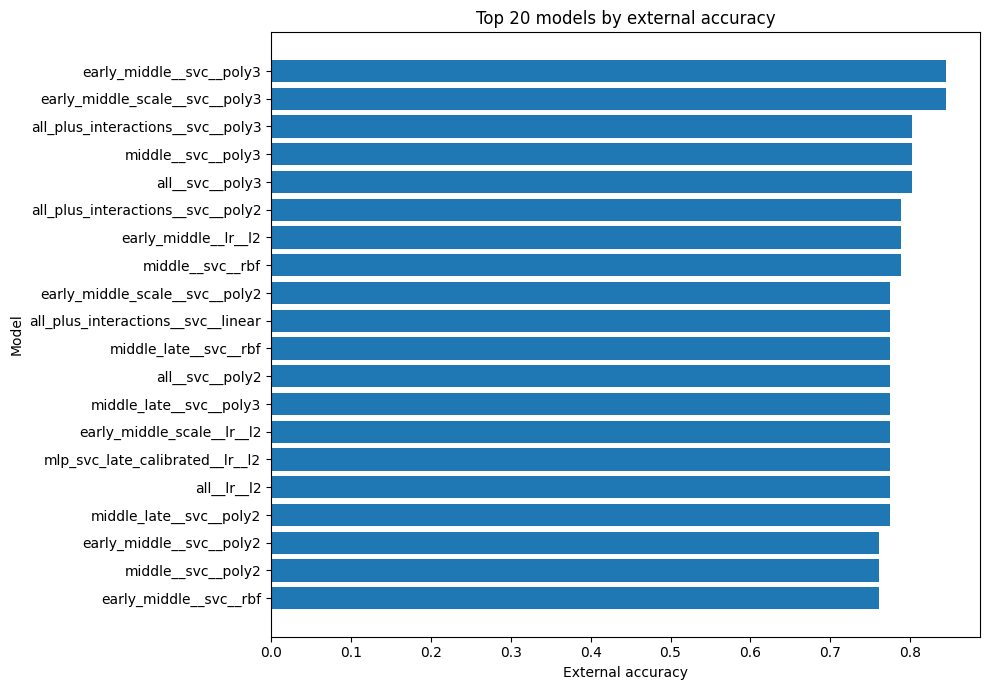

In [20]:
external = pd.read_csv(external_path)
top = external.sort_values(['accuracy', 'balanced_accuracy'], ascending=False).head(20).copy()
top_cols = [
    'model_name', 'group', 'feature_block', 'accuracy', 'balanced_accuracy',
    'sensitivity', 'specificity', 'f1', 'roc_auc', 'pr_auc', 'mcc', 'tn', 'fp', 'fn', 'tp'
]
external_metric_names = {
    col: f'external_{col}'
    for col in ['accuracy', 'balanced_accuracy', 'sensitivity', 'specificity', 'f1', 'roc_auc', 'pr_auc', 'mcc', 'tn', 'fp', 'fn', 'tp']
}
display(
    top[[c for c in top_cols if c in top.columns]]
    .rename(columns=external_metric_names)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 7))
plt.barh(top['model_name'][::-1], top['accuracy'][::-1])
plt.xlabel('External accuracy')
plt.ylabel('Model')
plt.title('Top 20 models by external accuracy')
plt.tight_layout()
plt.show()


## 2. All-model external metrics table


In [21]:
external_cols = [
    'model_name', 'group', 'feature_block', 'accuracy', 'balanced_accuracy',
    'sensitivity', 'specificity', 'f1', 'roc_auc', 'pr_auc', 'mcc', 'tn', 'fp', 'fn', 'tp'
]
external[external_cols].sort_values(
    ['accuracy', 'balanced_accuracy', 'sensitivity', 'specificity', 'f1', 'roc_auc', 'pr_auc'],
    ascending=False
).rename(columns=external_metric_names).reset_index(drop=True)


,model_name,group,feature_block,external_accuracy,external_balanced_accuracy,external_sensitivity,external_specificity,external_f1,external_roc_auc,external_pr_auc,external_mcc,external_tn,external_fp,external_fn,external_tp
0,early_middle__svc__poly3,two_stage_raw,early_middle,0.845070,0.846429,0.942857,0.750000,0.857143,0.856349,0.849876,0.704702,27,9,2,33
1,early_middle_scale__svc__poly3,sequential_scale,early_middle_scale,0.845070,0.846429,0.942857,0.750000,0.857143,0.849206,0.836852,0.704702,27,9,2,33
2,all_plus_interactions__svc__poly3,three_stage_full_interaction,all_plus_interactions,0.802817,0.804365,0.914286,0.694444,0.820513,0.841270,0.837007,0.622726,25,11,3,32
3,middle__svc__poly3,single_stage_middle_moderate,middle,0.802817,0.803968,0.885714,0.722222,0.815789,0.850000,0.857225,0.615306,26,10,4,31
4,all__svc__poly3,three_stage_raw,all,0.802817,0.803968,0.885714,0.722222,0.815789,0.850000,0.844211,0.615306,26,10,4,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,stage_activation_summary__svc__poly3,interaction_summary_only,stage_activation_summary,0.507042,0.509524,0.685714,0.333333,0.578313,0.552381,0.542280,0.020349,12,24,11,24
98,stage_activation_summary__svc__sigmoid,interaction_summary_only,stage_activation_summary,0.507042,0.507143,0.514286,0.500000,0.507042,0.542857,0.520164,0.014286,18,18,17,18
99,stage_activation_summary__svc__rbf,interaction_summary_only,stage_activation_summary,0.492958,0.495238,0.657143,0.333333,0.560976,0.545635,0.551231,-0.010066,12,24,12,23
100,stage_activation_summary__lr__elasticnet,interaction_summary_only,stage_activation_summary,0.492958,0.494048,0.571429,0.416667,0.526316,0.534921,0.504335,-0.012049,15,21,15,20


## 3. Sensitivity and specificity comparison


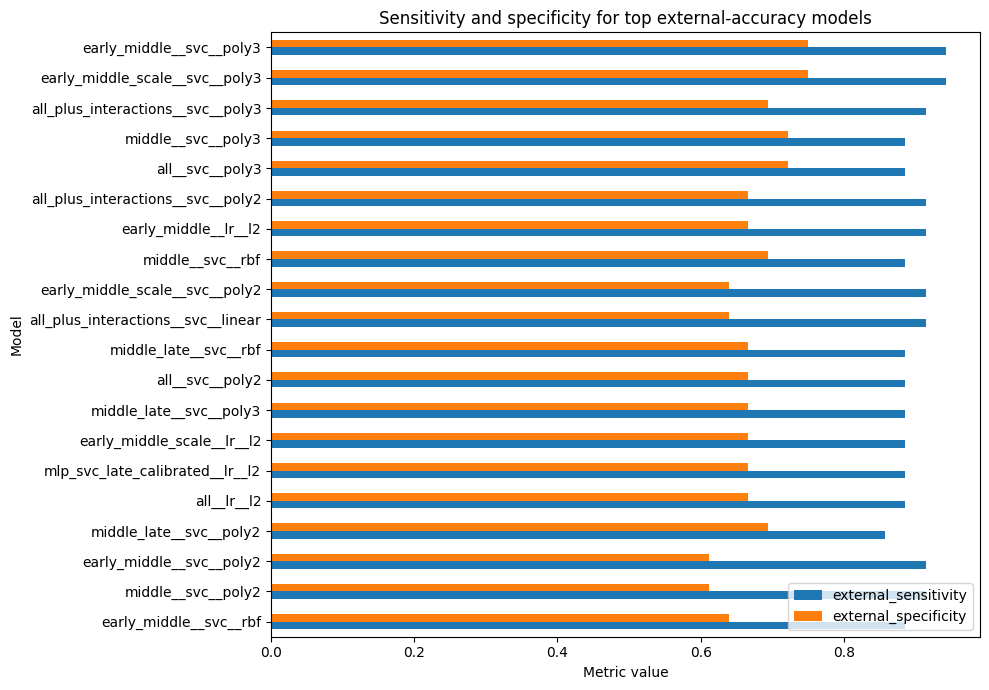

,external_sensitivity,external_specificity
model_name,,
early_middle__svc__poly3,0.942857,0.750000
early_middle_scale__svc__poly3,0.942857,0.750000
all_plus_interactions__svc__poly3,0.914286,0.694444
middle__svc__poly3,0.885714,0.722222
all__svc__poly3,0.885714,0.722222
all_plus_interactions__svc__poly2,0.914286,0.666667
early_middle__lr__l2,0.914286,0.666667
middle__svc__rbf,0.885714,0.694444
early_middle_scale__svc__poly2,0.914286,0.638889


In [22]:
top_metrics = (
    top[['model_name', 'sensitivity', 'specificity']]
    .rename(columns=external_metric_names)
    .set_index('model_name')
)
top_metrics.iloc[::-1].plot(kind='barh', figsize=(10, 7))
plt.xlabel('Metric value')
plt.ylabel('Model')
plt.title('Sensitivity and specificity for top external-accuracy models')
plt.tight_layout()
plt.show()
top_metrics


## 4. CV diagnostic table


In [23]:
cv = pd.read_csv(cv_path)
cv_cols = [
    'model_name', 'group', 'feature_block', 'cv_accuracy', 'cv_balanced_accuracy',
    'cv_sensitivity', 'cv_specificity', 'cv_f1', 'cv_roc_auc', 'cv_pr_auc', 'cv_mcc',
    'best_cv_score_grid', 'best_params'
]
cv[[c for c in cv_cols if c in cv.columns]].sort_values(['cv_accuracy', 'cv_balanced_accuracy'], ascending=False).reset_index(drop=True)


,model_name,group,feature_block,cv_accuracy,cv_balanced_accuracy,cv_sensitivity,cv_specificity,cv_f1,cv_roc_auc,cv_pr_auc,cv_mcc,best_cv_score_grid,best_params
0,middle__svc__poly2,single_stage_middle_moderate,middle,0.897590,0.898225,0.885057,0.911392,0.900585,0.957660,0.965308,0.795582,0.881699,"{""clf__C"": 3.0, ""clf__class_weight"": null, ""cl..."
1,middle_late__svc__poly2,two_stage_raw,middle_late,0.897590,0.897643,0.896552,0.898734,0.901734,0.958242,0.965653,0.794881,0.891682,"{""clf__C"": 1.0, ""clf__class_weight"": ""balanced..."
2,middle__svc__poly3,single_stage_middle_moderate,middle,0.897590,0.897061,0.908046,0.886076,0.902857,0.950677,0.959152,0.794642,0.861438,"{""clf__C"": 1.0, ""clf__class_weight"": null, ""cl..."
3,middle_late__svc__poly3,two_stage_raw,middle_late,0.897590,0.897061,0.908046,0.886076,0.902857,0.951841,0.959579,0.794642,0.867499,"{""clf__C"": 1.0, ""clf__class_weight"": null, ""cl..."
4,all_plus_interactions__lr__elasticnet,three_stage_full_interaction,all_plus_interactions,0.891566,0.893060,0.862069,0.924051,0.892857,0.963189,0.970311,0.785434,0.881640,"{""clf__C"": 1.0, ""clf__class_weight"": ""balanced..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,stage_activation_summary__lr__l2,interaction_summary_only,stage_activation_summary,0.572289,0.573912,0.540230,0.607595,0.569697,0.641132,0.615568,0.147922,0.590612,"{""clf__C"": 0.03, ""clf__class_weight"": null}"
98,stage_activation_summary__svc__sigmoid,interaction_summary_only,stage_activation_summary,0.566265,0.565837,0.574713,0.556962,0.581395,0.614070,0.622079,0.131560,0.603981,"{""clf__C"": 1.0, ""clf__class_weight"": ""balanced..."
99,late__lr__l2,single_stage_late_severe,late,0.548193,0.559654,0.321839,0.797468,0.427481,0.557035,0.567198,0.135000,0.546346,"{""clf__C"": 0.03, ""clf__class_weight"": null}"
100,late__lr__l1,single_stage_late_severe,late,0.542169,0.553907,0.310345,0.797468,0.415385,0.570420,0.577864,0.122902,0.536245,"{""clf__C"": 0.1, ""clf__class_weight"": null}"


## 5. Selected model confusion matrix and probability distribution


Selected model: early_middle__svc__poly3


Predicted,0,1
True,,
0,27,9
1,2,33


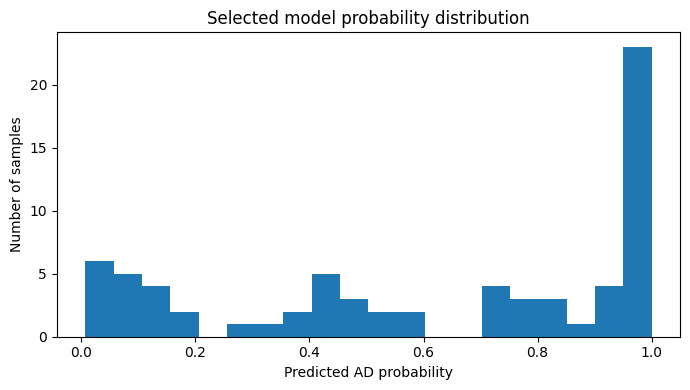

In [24]:
pred = pd.read_csv(pred_path)
selected_model = external.sort_values(['accuracy', 'balanced_accuracy'], ascending=False).iloc[0]['model_name']
sel_pred = pred[pred['model_name'] == selected_model].copy()
print('Selected model:', selected_model)
conf = pd.crosstab(sel_pred['y_true'], sel_pred['y_pred'], rownames=['True'], colnames=['Predicted'], dropna=False)
display(conf)
plt.figure(figsize=(7, 4))
plt.hist(sel_pred['p_ad'], bins=20)
plt.xlabel('Predicted AD probability')
plt.ylabel('Number of samples')
plt.title('Selected model probability distribution')
plt.tight_layout()
plt.show()


## 6. early / middle / late subgroup error analysis


,severity_group,n,external_accuracy,mean_p_ad,external_fn,external_fp
0,AD_high_MMSE,8,1.000000,0.826263,0,0
1,control,36,0.750000,0.395751,0,9
2,early,6,0.833333,0.762661,1,0
3,late,7,1.000000,0.930452,0,0
4,middle,14,0.928571,0.818643,1,0


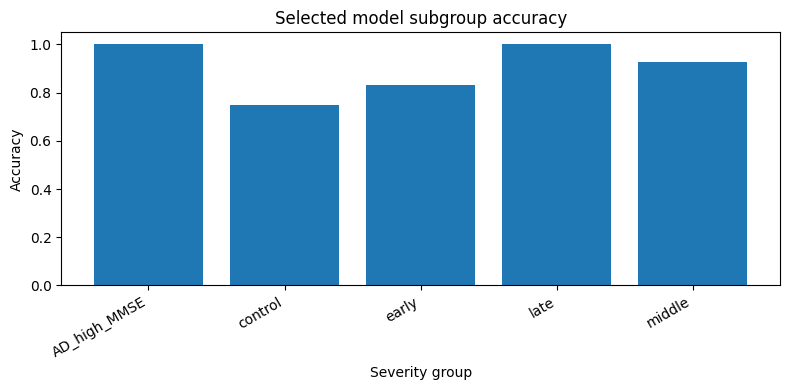

In [25]:
subgroup = (
    sel_pred.groupby('severity_group', dropna=False)
    .agg(n=('sample_id','count'), external_accuracy=('correct','mean'), mean_p_ad=('p_ad','mean'), external_fn=('error_type', lambda x: (x.astype(str).str.startswith('FN')).sum()), external_fp=('error_type', lambda x: (x == 'FP_normal').sum()))
    .reset_index()
)
display(subgroup)
plt.figure(figsize=(8, 4))
plt.bar(subgroup['severity_group'].astype(str), subgroup['external_accuracy'])
plt.xlabel('Severity group')
plt.ylabel('Accuracy')
plt.title('Selected model subgroup accuracy')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 7. Top 10 OOF prediction error table


In [26]:
oof = pd.read_csv(oof_path)
oof_errors = oof[oof['correct'] == 0].copy()
display(oof_errors[['model_name','sample_id','y_true','y_pred','p_ad','severity_group','mmse','error_type']].sort_values(['model_name','error_type']).head(100))


,model_name,sample_id,y_true,y_pred,p_ad,severity_group,mmse,error_type
696,all__svc__poly3,AD_0033,1,0,0.242445,early,23,FN_early
714,all__svc__poly3,AD_0051,1,0,0.197663,early,22,FN_early
721,all__svc__poly3,AD_0058,1,0,0.307809,early,22,FN_early
683,all__svc__poly3,AD_0020,1,0,0.192861,late,12,FN_late
698,all__svc__poly3,AD_0035,1,0,0.393565,late,11,FN_late
...,...,...,...,...,...,...,...,...
349,early_middle__lr__l2,AD_0018,1,0,0.133146,middle,14,FN_middle
350,early_middle__lr__l2,AD_0019,1,0,0.307343,middle,20,FN_middle
363,early_middle__lr__l2,AD_0032,1,0,0.056955,middle,20,FN_middle
400,early_middle__lr__l2,AD_0069,1,0,0.346450,middle,20,FN_middle


## 8. Model metrics joined table


In [27]:
joined = external.merge(cv, on=['model_name','group','feature_block'], how='left', suffixes=('_external','_cv'))
keep = [
    'model_name','group','feature_block',
    'accuracy','balanced_accuracy','sensitivity','specificity','f1','roc_auc','pr_auc','mcc',
    'cv_accuracy','cv_balanced_accuracy','cv_sensitivity','cv_specificity','cv_f1','cv_roc_auc','cv_pr_auc','cv_mcc'
]
joined[[c for c in keep if c in joined.columns]].sort_values(
    ['accuracy','balanced_accuracy'], ascending=False
).rename(columns=external_metric_names).reset_index(drop=True)


,model_name,group,feature_block,external_accuracy,external_balanced_accuracy,external_sensitivity,external_specificity,external_f1,external_roc_auc,external_pr_auc,external_mcc,cv_accuracy,cv_balanced_accuracy,cv_sensitivity,cv_specificity,cv_f1,cv_roc_auc,cv_pr_auc,cv_mcc
0,early_middle__svc__poly3,two_stage_raw,early_middle,0.845070,0.846429,0.942857,0.750000,0.857143,0.856349,0.849876,0.704702,0.885542,0.884985,0.896552,0.873418,0.891429,0.956642,0.963390,0.770474
1,early_middle_scale__svc__poly3,sequential_scale,early_middle_scale,0.845070,0.846429,0.942857,0.750000,0.857143,0.849206,0.836852,0.704702,0.879518,0.879238,0.885057,0.873418,0.885057,0.954168,0.961304,0.758475
2,all_plus_interactions__svc__poly3,three_stage_full_interaction,all_plus_interactions,0.802817,0.804365,0.914286,0.694444,0.820513,0.841270,0.837007,0.622726,0.861446,0.861414,0.862069,0.860759,0.867052,0.942383,0.951301,0.722461
3,middle__svc__poly3,single_stage_middle_moderate,middle,0.802817,0.803968,0.885714,0.722222,0.815789,0.850000,0.857225,0.615306,0.897590,0.897061,0.908046,0.886076,0.902857,0.950677,0.959152,0.794642
4,all__svc__poly3,three_stage_raw,all,0.802817,0.803968,0.885714,0.722222,0.815789,0.850000,0.844211,0.615306,0.879518,0.878656,0.896552,0.860759,0.886364,0.957515,0.963759,0.758415
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,stage_activation_summary__svc__poly3,interaction_summary_only,stage_activation_summary,0.507042,0.509524,0.685714,0.333333,0.578313,0.552381,0.542280,0.020349,0.638554,0.631311,0.781609,0.481013,0.693878,0.626582,0.593893,0.276219
98,stage_activation_summary__svc__sigmoid,interaction_summary_only,stage_activation_summary,0.507042,0.507143,0.514286,0.500000,0.507042,0.542857,0.520164,0.014286,0.566265,0.565837,0.574713,0.556962,0.581395,0.614070,0.622079,0.131560
99,stage_activation_summary__svc__rbf,interaction_summary_only,stage_activation_summary,0.492958,0.495238,0.657143,0.333333,0.560976,0.545635,0.551231,-0.010066,0.632530,0.625564,0.770115,0.481013,0.687179,0.602430,0.578116,0.263052
100,stage_activation_summary__lr__elasticnet,interaction_summary_only,stage_activation_summary,0.492958,0.494048,0.571429,0.416667,0.526316,0.534921,0.504335,-0.012049,0.602410,0.600320,0.643678,0.556962,0.629213,0.638222,0.614555,0.201344
